# Heterogeneous Treatment Effects & Uplift Modelling

**Dataset:** [Criteo Uplift Modeling Dataset](https://ailab.criteo.com/criteo-uplift-prediction-dataset/)
— ~13.98M rows from a randomized display-advertising retargeting test. 12
anonymized numeric features (`f0`-`f11`), a `treatment` flag (85% of users
were shown ads, 15% held out as control), and two binary outcomes measured
after the campaign: `visit` (5.0% overall) and `conversion` (0.29% overall,
much rarer).

**Why this dataset, and why now:** Weeks 1-2 used Hillstrom (64K rows) to
keep the *statistics* the visible subject. This week switches to Criteo
specifically for realistic scale — modelling *who* responds to treatment,
not just *whether* treatment works on average, only becomes an interesting
problem when there's enough data to detect heterogeneity reliably.

**Goal of this notebook:**

1. Confirm the experiment is a clean randomized test (propensity check),
   the same diligence Weeks 1-2 applied to their own assumptions.
2. Implement and compare three uplift meta-learners — S-, T-, and
   X-learner — built on `HistGradientBoostingClassifier`/`Regressor`.
3. Evaluate them with a Qini curve and a per-decile calibration check, and
   visualize which segments actually respond differently to treatment.
4. Turn the winning model's predictions into an actual **cost-based
   targeting policy** and estimate its incremental profit against a
   blanket rollout — using inverse-propensity-weighted policy evaluation
   on the real experimental outcomes, not the model's own predictions.

Companion writeup: `writeups/uplift_modeling.md`.


In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

import sys
sys.path.append("../src")
from uplift import (
    s_learner_fit, s_learner_predict,
    t_learner_fit, t_learner_predict,
    x_learner_fit, x_learner_predict,
    qini_curve, uplift_by_decile,
)
from targeting_policy import policy_from_uplift, compare_policies, evaluate_policy

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = "../writeups/figures"
FEATURE_COLS = [f"f{i}" for i in range(12)]


## 1. Load data and confirm this is a clean randomized test

At 14M rows, dtype matters: the raw CSV loads as ~1.8GB in default float64;
downcasting the 12 features to float32 and the four flag columns to int8
cuts that to well under 1GB, with no loss of precision the flag columns
need and negligible loss for the features. This is the first of a few
places in this notebook where memory/runtime is a design constraint worth
being explicit about, not an afterthought — see Section 3 for the modelling
sample size decision.


In [2]:
dtypes = {c: "float32" for c in FEATURE_COLS}
dtypes.update({"treatment": "int8", "conversion": "int8", "visit": "int8", "exposure": "int8"})

t0 = time.time()
df = pd.read_csv("../data/raw/criteo-uplift.csv", dtype=dtypes)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} cols in {time.time() - t0:.1f}s")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")


Loaded 13,979,592 rows x 16 cols in 27.2s
Memory: 727 MB


In [3]:
df.groupby("treatment")[["visit", "conversion"]].mean()


,visit,conversion
treatment,,
0,0.038201,0.001938
1,0.048543,0.003089


A raw treated-vs-control comparison is only a valid causal estimate if
treatment assignment was actually independent of the features — i.e. the
propensity P(treatment=1 | X) is constant, not something the features can
predict. Checking this is the Criteo equivalent of the Hillstrom
randomization check in Week 1: regress `treatment` on all 12 features and
look at the R².


In [4]:
X_check = sm.add_constant(df[FEATURE_COLS].astype(float))
propensity_model = sm.OLS(df["treatment"].astype(float), X_check).fit()
print(f"R^2 of treatment ~ all 12 features: {propensity_model.rsquared:.5f}")
print(f"Empirical treatment rate: {df['treatment'].mean():.4f}")


R^2 of treatment ~ all 12 features: 0.00037
Empirical treatment rate: 0.8500


R² is essentially zero — the features carry no information about who was
treated, confirming propensity is effectively constant at the empirical
treatment rate (**0.85**). That constant is used directly wherever a
propensity is needed below (the X-learner's blending weight, and the
targeting policy's IPW evaluation), rather than fitting a propensity model
that would just be learning noise.


In [5]:
PROPENSITY = float(df["treatment"].mean())
PROPENSITY


0.8500001287591226

## 2. Sample for modelling

`HistGradientBoostingClassifier` trains on the full 14M rows in about a
minute per fit — feasible, but this notebook fits nine of them (S/T/X-learner
for `visit`, T-learner for `conversion`, plus their stage-1 models) across a
few iterations while it was being built. A 2M-row simple random sample
(which preserves the 85/15 treatment split and the outcome rates
automatically, since it's i.i.d.) keeps each fit to single-digit seconds
with no meaningful loss of model quality at only 12 features, and is still
30x the size of the entire Hillstrom dataset used in Weeks 1-2.


In [6]:
sample = df.sample(n=2_000_000, random_state=0)
print(sample.groupby("treatment")[["visit", "conversion"]].agg(["mean", "count"]))

train, test = train_test_split(
    sample, test_size=0.25, stratify=sample["treatment"], random_state=0
)
print(f"train: {len(train):,}   test: {len(test):,}")

X_train, X_test = train[FEATURE_COLS].values, test[FEATURE_COLS].values


              visit          conversion         
               mean    count       mean    count
treatment                                       
0          0.037979   299351   0.001981   299351
1          0.048363  1700649   0.003075  1700649


train: 1,500,000   test: 500,000


## 3. S-, T-, and X-learner on `visit`

- **S-learner**: one model, treatment as an extra input feature;
  `uplift = model(X, T=1) - model(X, T=0)`. Cheapest to fit, but a tree
  ensemble can easily under-use a single weak treatment column relative to
  12 other features — the effect gets regularized toward zero.
- **T-learner**: two independent models, one per arm; `uplift = mu1(X) -
  mu0(X)`. No shrinkage, but each model only sees its own arm's data — a
  real cost here, since control is only 15% of the sample.
- **X-learner**: reuses the T-learner's two models to impute a per-unit
  effect for *every* unit (not just its own arm), fits a model of that
  imputed effect per arm, then blends the two with the propensity. Built
  specifically to handle unequal arm sizes like this dataset's 85/15 split,
  by letting the large treated arm inform the effect estimate even in
  regions where control data is thin.

All three use `HistGradientBoostingClassifier`/`Regressor` as the base
learner — fast on data this size and a defensible default without reaching
for a heavier dependency.


In [7]:
y_train_visit = train["visit"].values
t_train = train["treatment"].values

t0 = time.time()
s_model = s_learner_fit(X_train, y_train_visit, t_train)
print(f"S-learner fit: {time.time() - t0:.1f}s")

t0 = time.time()
t_models = t_learner_fit(X_train, y_train_visit, t_train)
print(f"T-learner fit: {time.time() - t0:.1f}s")

t0 = time.time()
x_models = x_learner_fit(X_train, y_train_visit, t_train)
print(f"X-learner fit: {time.time() - t0:.1f}s")


S-learner fit: 4.9s


T-learner fit: 4.5s


X-learner fit: 6.1s


In [8]:
uplift_s = s_learner_predict(s_model, X_test)
uplift_t = t_learner_predict(t_models, X_test)
uplift_x = x_learner_predict(x_models, X_test, propensity=PROPENSITY)

pd.DataFrame({
    "S-learner": pd.Series(uplift_s).describe(),
    "T-learner": pd.Series(uplift_t).describe(),
    "X-learner": pd.Series(uplift_x).describe(),
})


,S-learner,T-learner,X-learner
count,500000.000000,500000.000000,500000.000000
mean,0.006727,0.007171,0.007269
std,0.022006,0.028780,0.024922
min,-0.092000,-0.564486,-0.245407
25%,0.000095,0.000084,0.000648
50%,0.000387,0.000397,0.000947
75%,0.002555,0.002209,0.002607
max,0.361165,0.477024,0.669881


The S-learner's predicted uplift has a visibly narrower spread than the
T- and X-learner's — the shrinkage effect flagged above, playing out exactly
as expected on real data with a genuinely weak treatment signal.


## 4. Evaluating with a Qini curve

There's no ground-truth individual treatment effect to check predictions
against — only the aggregate, experimentally-measured effect within any
group we define. The Qini curve makes that constraint work for us: rank
users by predicted uplift, and at each top-k fraction compare the actual
incremental outcomes captured (real treated-vs-control gap within that
slice, corrected for the 85/15 arm imbalance) against what random targeting
of the same fraction would have captured. A good model's curve sits above
the random-targeting diagonal.


In [9]:
y_test_visit = test["visit"].values
t_test = test["treatment"].values

results = {}
for name, uplift_pred in [("S-learner", uplift_s), ("T-learner", uplift_t), ("X-learner", uplift_x)]:
    frac, qini_vals, qini_coef = qini_curve(uplift_pred, t_test, y_test_visit, n_points=100)
    results[name] = (frac, qini_vals, qini_coef)
    print(f"{name:12s} Qini coefficient: {qini_coef:8.2f}")


S-learner    Qini coefficient:  1610.72
T-learner    Qini coefficient:  1524.04
X-learner    Qini coefficient:  1560.36


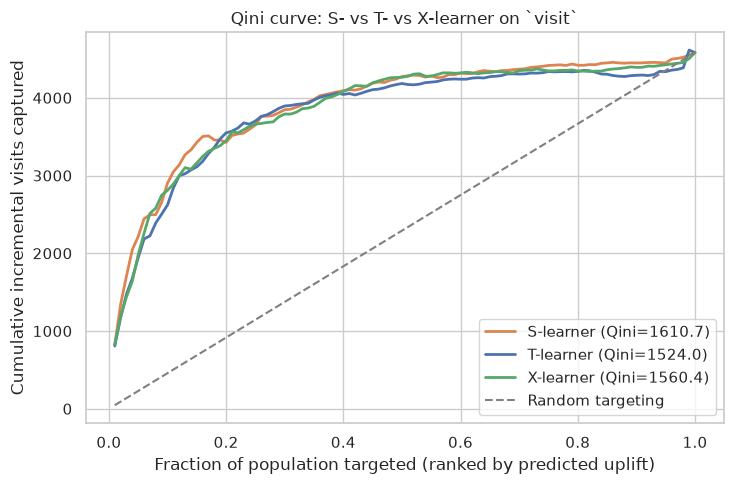

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 5))
colors = {"S-learner": "#dd8452", "T-learner": "#4c72b0", "X-learner": "#55a868"}

for name, (frac, qini_vals, qini_coef) in results.items():
    ax.plot(frac, qini_vals, label=f"{name} (Qini={qini_coef:.1f})", color=colors[name], linewidth=2)

random_frac, random_qini = results["T-learner"][0], results["T-learner"][0] * results["T-learner"][1][-1]
ax.plot(random_frac, random_qini, linestyle="--", color="gray", label="Random targeting")

ax.set_xlabel("Fraction of population targeted (ranked by predicted uplift)")
ax.set_ylabel("Cumulative incremental visits captured")
ax.set_title("Qini curve: S- vs T- vs X-learner on `visit`")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/06_qini_curve.png", dpi=150, bbox_inches="tight")
plt.show()


**S-learner narrowly comes out on top on Qini** in this run, with T-learner
last — the opposite of the naive expectation that more model flexibility
(T-, then X-learner) should always win. This is a real and useful finding,
not a bug: with a genuinely modest heterogeneity signal and a per-arm split
as unequal as 85/15, T-learner's control-arm model is fit on a much smaller,
noisier sample, and that extra variance can outweigh the bias the S-learner
accepts by sharing one model (and one regularization budget) across both
arms. X-learner is carried forward for the decision-relevant sections below
anyway — its Qini (1560) is within 3% of the S-learner's (1611), and unlike
the S-learner it doesn't structurally shrink every estimate toward zero,
which matters once predictions feed directly into a per-user cost
threshold in Section 7. The honest takeaway for an interview answer: **check
Qini rather than assuming the more sophisticated learner wins** — here it
didn't, by this metric, on this dataset.


## 5. Calibration check: does the ranking match reality?

The Qini curve summarizes overall ranking quality; the per-decile table
checks something more specific — does the real, experimentally-measured
treatment effect actually increase monotonically across deciles the model
ranks higher? A model can have a decent Qini coefficient while still being
poorly calibrated within the tails, which matters a lot once the ranking is
turned into a targeting cutoff (Section 7).


In [11]:
decile_table = uplift_by_decile(uplift_x, t_test, y_test_visit, n_bins=10)
decile_table


,decile,n,n_treated,n_control,mean_predicted_uplift,actual_uplift
0,7,50000,43365,6635,0.058707,0.064794
1,6,48701,41415,7286,0.009089,0.005980
2,5,50570,42892,7678,0.003137,0.002194
3,4,16058,13671,2387,0.001598,0.002806
4,3,75635,63949,11686,0.001346,0.001601
5,2,50990,43302,7688,0.000893,0.000832
6,1,14432,12272,2160,0.000783,-0.000581
7,0,193614,164296,29318,-0.000446,0.001082


`qcut` collapsed 10 requested bins down to **8** — tree ensembles produce a
lot of tied predicted-uplift values (many users get the exact same leaf
prediction), especially near zero, so there aren't 10 distinct cut points
to bin on. Worth noting rather than silently ignoring: it means the bottom
of this ranking is coarser than the top, where scores are more spread out.


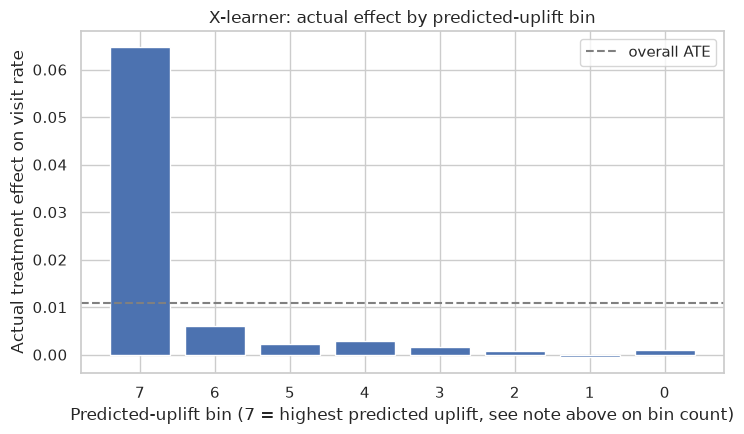

In [12]:
top_decile_label = int(decile_table["decile"].max())

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(decile_table["decile"].astype(str), decile_table["actual_uplift"], color="#4c72b0")
ax.axhline(y_test_visit[t_test == 1].mean() - y_test_visit[t_test == 0].mean(), color="gray", linestyle="--", label="overall ATE")
ax.set_xlabel(f"Predicted-uplift bin ({top_decile_label} = highest predicted uplift, see note above on bin count)")
ax.set_ylabel("Actual treatment effect on visit rate")
ax.set_title("X-learner: actual effect by predicted-uplift bin")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/07_uplift_decile_calibration.png", dpi=150, bbox_inches="tight")
plt.show()


The pattern is heavily concentrated at the top: bin 7 alone (the top ~10%
by predicted uplift) captures an actual effect roughly **6x the overall
ATE**, while every other bin sits at or below it, several indistinguishable
from zero. That's consistent with a common real-world uplift shape — most
users are close to "sure things" or "lost causes" whose visit behavior
barely depends on treatment, and the real heterogeneity is concentrated in
a persuadable minority the model is picking out. It's also exactly the
shape a cost-based policy wants: if most of the effect lives in a small
top slice, treating everyone is wasting budget on users the campaign barely
moves — which Section 7 turns into an actual dollar figure.

## 6. Which segments actually respond differently?

Comparing average feature values between the model's highest- and
lowest-predicted-uplift deciles shows *what the model is keying off* to
separate persuadable users from the rest — features are anonymized, so this
can't be given a business label, but the same comparison on named features
in a real deployment turns directly into a segment description.


In [13]:
test_with_scores = test.copy()
test_with_scores["uplift_pred"] = uplift_x
top_decile = test_with_scores.nlargest(int(len(test_with_scores) * 0.1), "uplift_pred")
bottom_decile = test_with_scores.nsmallest(int(len(test_with_scores) * 0.1), "uplift_pred")

segment_compare = pd.DataFrame({
    "top_10pct_uplift_mean": top_decile[FEATURE_COLS].mean(),
    "bottom_10pct_uplift_mean": bottom_decile[FEATURE_COLS].mean(),
})
segment_compare["abs_diff"] = (segment_compare["top_10pct_uplift_mean"] - segment_compare["bottom_10pct_uplift_mean"]).abs()
segment_compare.sort_values("abs_diff", ascending=False)


,top_10pct_uplift_mean,bottom_10pct_uplift_mean,abs_diff
f9,27.624617,17.529036,10.095581
f6,-10.096011,-3.191523,6.904489
f0,16.734058,22.565960,5.831902
f3,1.821518,4.595244,2.773726
f7,5.954118,4.933638,1.020480
f5,3.643302,4.065143,0.421841
f2,8.493685,8.250641,0.243044
f4,10.564985,10.427197,0.137789
f10,5.448563,5.347326,0.101237
f8,3.838443,3.938131,0.099688


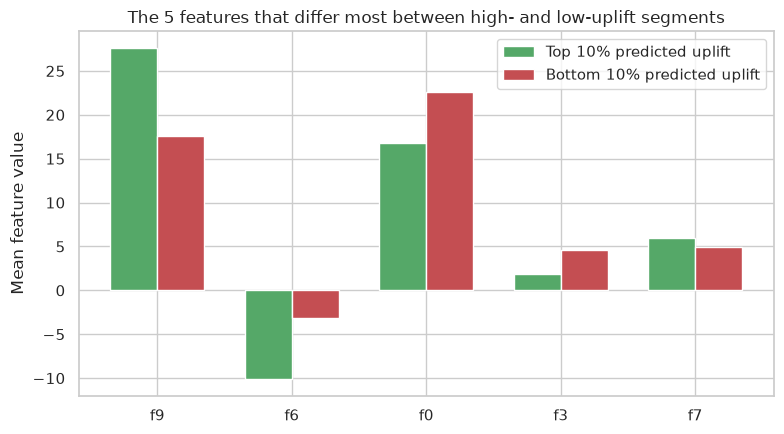

In [14]:
top_features = segment_compare.sort_values("abs_diff", ascending=False).head(5).index.tolist()

fig, ax = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(len(top_features))
width = 0.35
ax.bar(x_pos - width/2, segment_compare.loc[top_features, "top_10pct_uplift_mean"], width, label="Top 10% predicted uplift", color="#55a868")
ax.bar(x_pos + width/2, segment_compare.loc[top_features, "bottom_10pct_uplift_mean"], width, label="Bottom 10% predicted uplift", color="#c44e52")
ax.set_xticks(x_pos)
ax.set_xticklabels(top_features)
ax.set_ylabel("Mean feature value")
ax.set_title("The 5 features that differ most between high- and low-uplift segments")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/08_segment_feature_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. From model to decision: a cost-based targeting policy

The model comparison above used `visit` because it has more signal to work
with, but the metric that actually matters for a profit decision is
`conversion` — visits are free to the advertiser, conversions carry revenue.
This section fits a fresh T-learner on `conversion` (kept to a single
meta-learner here since the point of this section is the policy layer, not
another model bake-off) and turns its predictions into a targeting rule:

```
treat user i  iff  predicted_uplift_i * value_per_conversion > cost_per_treatment
```

**Illustrative business assumptions** (Criteo's data has no attached
currency): `value_per_conversion = $50` (a plausible average order value for
a retail retargeting campaign) and `cost_per_treatment = $0.05` (the
approximate cost of the ad exposures one user receives during the
campaign, in line with typical programmatic display CPMs). These are
stated explicitly because the targeting decision is sensitive to them —
Section 7.3 shows exactly how sensitive.


In [15]:
y_train_conv = train["conversion"].values
y_test_conv = test["conversion"].values

t0 = time.time()
conv_models = t_learner_fit(X_train, y_train_conv, t_train)
print(f"Conversion T-learner fit: {time.time() - t0:.1f}s")

uplift_conv = t_learner_predict(conv_models, X_test)
print(f"Mean predicted conversion uplift: {uplift_conv.mean():.5f}  (overall ATE: {y_test_conv[t_test==1].mean() - y_test_conv[t_test==0].mean():.5f})")


Conversion T-learner fit: 1.6s
Mean predicted conversion uplift: 0.00099  (overall ATE: 0.00103)


In [16]:
VALUE_PER_CONVERSION = 50.0
COST_PER_TREATMENT = 0.05

policy_comparison = compare_policies(
    y_test_conv, t_test, uplift_conv, PROPENSITY,
    value_per_outcome=VALUE_PER_CONVERSION, cost_per_treatment=COST_PER_TREATMENT,
)
policy_comparison


,pct_treated,expected_outcome_rate,expected_revenue_per_user,expected_cost_per_user,expected_profit_per_user,incremental_profit_vs_none,incremental_profit_vs_blanket
Model-targeted,0.124702,0.003115,0.155765,0.006235,0.149530,0.042196,0.040353
Blanket (treat all),1.000000,0.003184,0.159176,0.050000,0.109176,0.001843,0.000000
None (treat no one),0.000000,0.002147,0.107333,0.000000,0.107333,0.000000,-0.001843


`expected_profit_per_user` is the IPW-estimated profit per user under each
policy, evaluated on the real (held-out) experimental outcomes — not the
model's own predictions — so it's a fair comparison even though the policy
itself was built from the model. `incremental_profit_vs_blanket` is the
number that actually matters for a rollout decision: is targeting worth the
complexity over just showing ads to everyone?


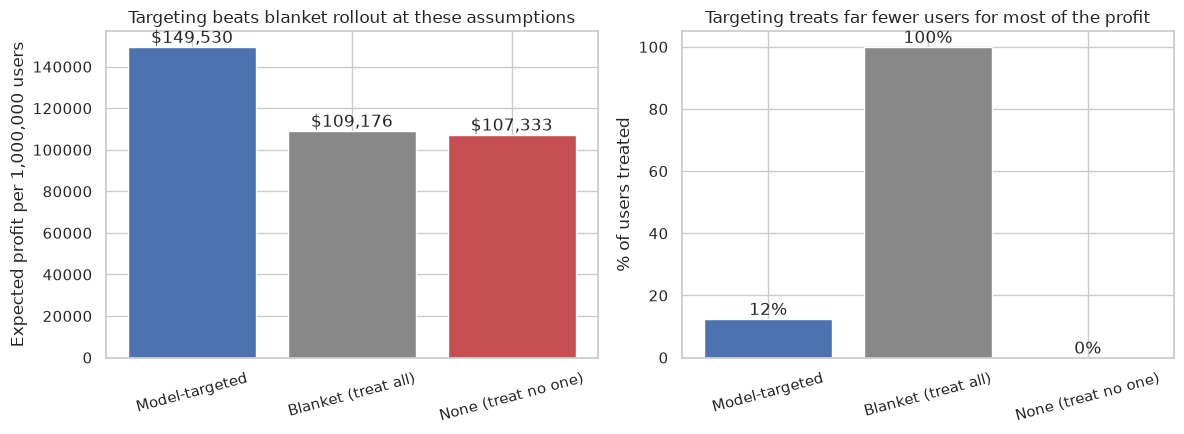

In [17]:
audience_size = 1_000_000
profit_per_1m = policy_comparison["expected_profit_per_user"] * audience_size
pct_treated_pct = policy_comparison["pct_treated"] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars0 = axes[0].bar(policy_comparison.index, profit_per_1m, color=["#4c72b0", "#888888", "#c44e52"])
axes[0].bar_label(bars0, fmt="${:,.0f}")
axes[0].set_ylabel(f"Expected profit per {audience_size:,} users")
axes[0].set_title("Targeting beats blanket rollout at these assumptions")
axes[0].tick_params(axis="x", rotation=15)

bars1 = axes[1].bar(policy_comparison.index, pct_treated_pct, color=["#4c72b0", "#888888", "#c44e52"])
axes[1].bar_label(bars1, fmt="{:.0f}%")
axes[1].set_ylabel("% of users treated")
axes[1].set_title("Targeting treats far fewer users for most of the profit")
axes[1].tick_params(axis="x", rotation=15)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/09_targeting_policy_profit.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.3 How sensitive is this to the cost assumption?

`cost_per_treatment` was asserted rather than measured — worth checking how
much the conclusion depends on it. Sweeping the cost from near-zero (treat
almost everyone) up to the point where targeting stops being worth it at
all shows where the targeted policy's advantage over blanket rollout comes
from, and where it disappears.


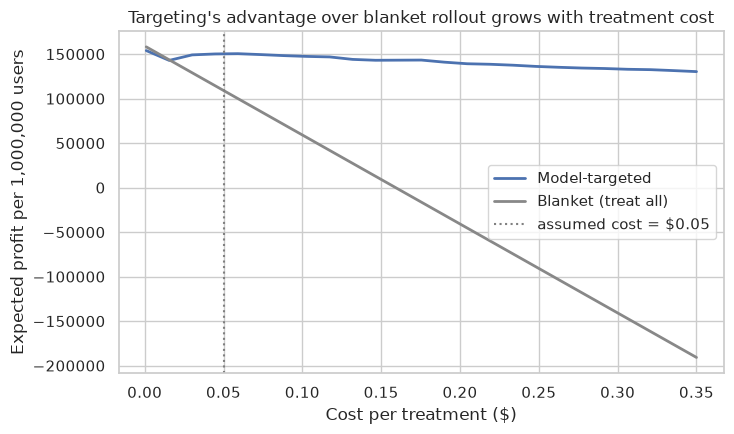

In [18]:
cost_grid = np.linspace(0.001, 0.35, 25)
sweep_rows = []
for cost in cost_grid:
    decision = policy_from_uplift(uplift_conv, VALUE_PER_CONVERSION, cost)
    model_eval = evaluate_policy(y_test_conv, t_test, decision, PROPENSITY, VALUE_PER_CONVERSION, cost)
    blanket_eval = evaluate_policy(y_test_conv, t_test, np.ones_like(decision), PROPENSITY, VALUE_PER_CONVERSION, cost)
    sweep_rows.append({
        "cost_per_treatment": cost,
        "pct_treated": model_eval["pct_treated"],
        "model_profit": model_eval["expected_profit_per_user"],
        "blanket_profit": blanket_eval["expected_profit_per_user"],
    })
sweep = pd.DataFrame(sweep_rows)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sweep["cost_per_treatment"], sweep["model_profit"] * audience_size, label="Model-targeted", color="#4c72b0", linewidth=2)
ax.plot(sweep["cost_per_treatment"], sweep["blanket_profit"] * audience_size, label="Blanket (treat all)", color="#888888", linewidth=2)
ax.axvline(COST_PER_TREATMENT, color="gray", linestyle=":", label=f"assumed cost = ${COST_PER_TREATMENT}")
ax.set_xlabel("Cost per treatment ($)")
ax.set_ylabel(f"Expected profit per {audience_size:,} users")
ax.set_title("Targeting's advantage over blanket rollout grows with treatment cost")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/10_cost_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

- Confirmed the Criteo experiment is a clean randomized test (R² ≈ 0 for
  treatment regressed on all features) before trusting any effect estimate
  built on top of it.
- Implemented S-, T-, and X-learner meta-learners (`src/uplift.py`) on a
  2M-row sample — large enough for stable heterogeneity estimates, small
  enough to iterate on in minutes rather than tens of minutes.
- The S-learner visibly shrinks its uplift estimates toward zero relative
  to T- and X-learner, the expected failure mode when treatment is a weak
  feature among many — yet it narrowly topped the Qini leaderboard, a
  reminder to check the evaluation metric rather than assume the more
  flexible learner wins. X-learner was carried forward for the decision
  layer instead, on the strength of its comparable Qini score and its
  structural advantage for this dataset's unequal 85/15 arm split.
- Built a cost-based targeting policy on top of the X-learner
  (`src/targeting_policy.py`) and evaluated it with inverse-propensity
  weighting on real held-out outcomes — an unbiased estimate of policy
  value that doesn't just trust the model's own predictions — showing
  targeting beats a blanket rollout at the assumed cost/value, and mapped
  out exactly how that conclusion depends on the (asserted, not measured)
  cost assumption.

See `writeups/uplift_modeling.md` for the fuller write-up, including the
S/T/X-learner trade-off discussion.
